In [ ]:
!pip install pandas numpy matplotlib scipy

Loaded CSV files: ['Energía Contador Energía Fase 1 Central.csv', 'Energía Contador Energía Fase 2 Central.csv']

Leyendo: Energía Contador Energía Fase 1 Central.csv
Columnas: Index(['endpoint', 'id', 'variable', 'fecha', 'valor'], dtype='object')

Leyendo: Energía Contador Energía Fase 2 Central.csv
Columnas: Index(['endpoint', 'id', 'variable', 'fecha', 'valor'], dtype='object')


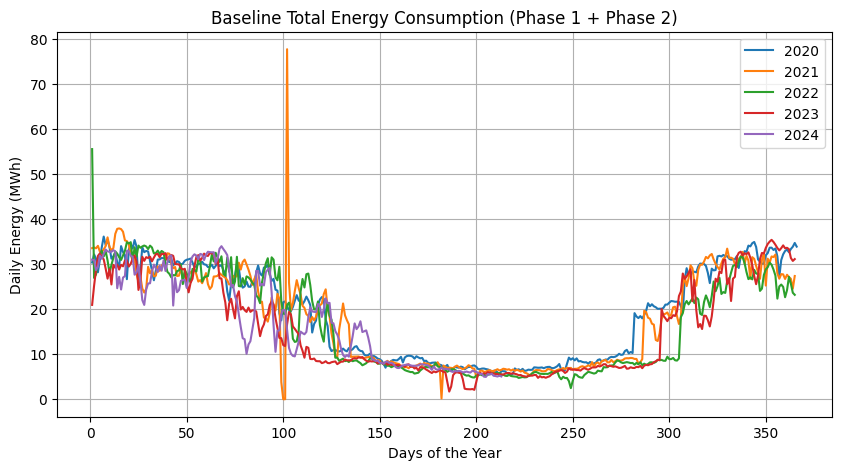

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# CONFIG
# ==============================
YEARS = [2020, 2021, 2022, 2023, 2024]

VAR_F1 = "Energía Contador Energía Fase 1 Central"
VAR_F2 = "Energía Contador Energía Fase 2 Central"

# ==============================
# LOAD CSVs
# ==============================

files = [
    "Energía Contador Energía Fase 1 Central.csv",
    "Energía Contador Energía Fase 2 Central.csv"
]

print("Loaded CSV files:", files)

dfs = []

for f in files:

    print("\nLeyendo:", f)

    df = pd.read_csv(f)

    df.columns = df.columns.str.lower().str.strip()

    print("Columnas:", df.columns)

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    df["valor"] = (
        df["valor"].astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

    dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    df = df[df["fecha"].dt.year.isin(YEARS)]

# ==============================
# 2️⃣ FILTER PHASE 1 & PHASE 2
# ==============================
f1 = df[df["variable"].str.contains(VAR_F1, case=False, na=False)].copy()
f2 = df[df["variable"].str.contains(VAR_F2, case=False, na=False)].copy()

f1 = f1.sort_values("fecha")
f2 = f2.sort_values("fecha")

# ==============================
# 3️⃣ HANDLE CUMULATIVE VARIABLE (DIFF)
# ==============================
f1["energy_f1"] = f1["valor"].diff()
f2["energy_f2"] = f2["valor"].diff()

f1 = f1[f1["energy_f1"] >= 0]
f2 = f2[f2["energy_f2"] >= 0]

# ==============================
# 4️⃣ MERGE TOTAL ENERGY
# ==============================
energy = pd.merge(
    f1[["fecha","energy_f1"]],
    f2[["fecha","energy_f2"]],
    on="fecha",
    how="inner"
)

energy["total_energy"] = energy["energy_f1"] + energy["energy_f2"]


# ==============================
# 5️⃣ DAILY BASELINE
# ==============================
daily = (
    energy.set_index("fecha")["total_energy"]
    .resample("1D").sum()
    .reset_index()
)

daily["year"] = daily["fecha"].dt.year
daily["day_of_year"] = daily["fecha"].dt.dayofyear

# ==============================
# 6️⃣ PLOT BASELINE
# ==============================
plt.figure(figsize=(10,5))

for y in YEARS:
    temp = daily[daily["year"] == y]
    plt.plot(temp["day_of_year"], temp["total_energy"], label=str(y))

plt.title("Baseline Total Energy Consumption (Phase 1 + Phase 2)")
plt.xlabel("Days of the Year")
plt.ylabel("Daily Energy (MWh)")
plt.legend()
plt.grid(True)
plt.show()





¿Fecha inicio? (YYYY-MM-DD): 2022-01-01
¿Fecha fin? (YYYY-MM-DD): 2022-12-31


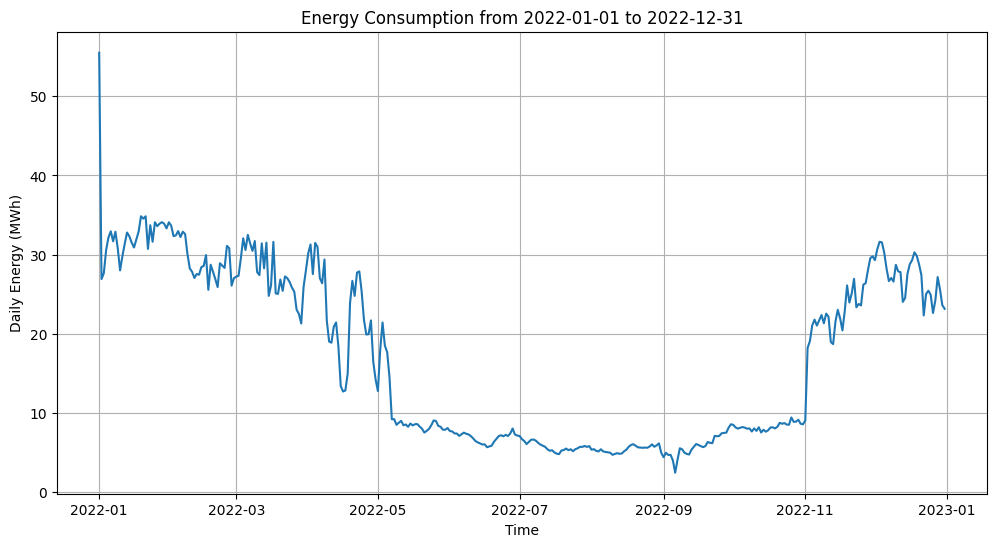

In [ ]:
# ==============================
# PREGUNTAR por un RANGO
# ==============================

start_date = input("¿Fecha inicio? (YYYY-MM-DD): ")
end_date = input("¿Fecha fin? (YYYY-MM-DD): ")

# convertir fechas
start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)

# filtrar rango
daily_range = daily[
    (daily["fecha"] >= start_date) &
    (daily["fecha"] <= end_date)
]

# ==============================
# GRÁFICA DEL RANGO
# ==============================
plt.figure(figsize=(12,6))

plt.plot(
    daily_range["fecha"],
    daily_range["total_energy"]
)

plt.title(f"Energy Consumption from {start_date.date()} to {end_date.date()}")
plt.xlabel("Time")
plt.ylabel("Daily Energy (MWh)")
plt.grid(True)

plt.show()



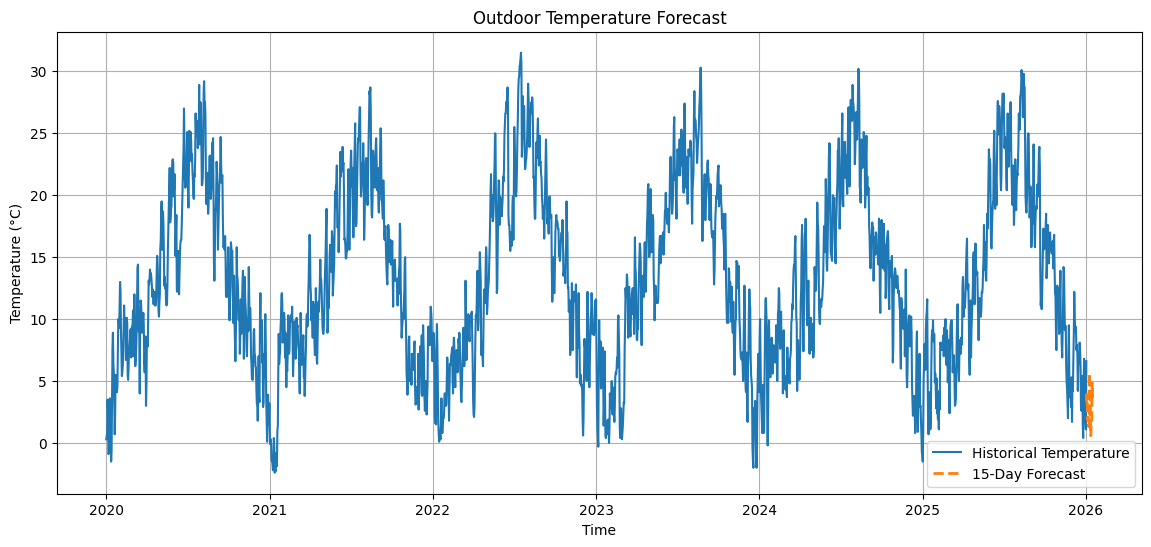

In [ ]:
# ============================================
# 1. LIBRERÍAS
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# ============================================
# 2. LEER CSVs WEATHER
# ============================================

df1 = pd.read_csv(
    "20260506 Weather History Daily 41.6543639,-4.7222733 20200101-20210101 - Sheet1 (1).csv"
)

df2 = pd.read_csv(
    "20260504 Weather History Daily 41.6543639,-4.7222733 20210101-20220101 - Sheet1.csv"
)

df3 = pd.read_csv(
    "20260504 Weather History Daily 41.6543639,-4.7222733 20220101-20230101 - Sheet1.csv"
)

df4 = pd.read_csv(
    "20260504 Weather History Daily 41.6543639,-4.7222733 20230101-20240101 - Sheet1 (1).csv"
)

df5 = pd.read_csv(
    "20260504 Weather History Daily 41.6543639,-4.7222733 20240101-20250101 - Sheet1.csv"
)

df6 = pd.read_csv(
    "20260504 Weather History Daily 41.6543639,-4.7222733 20250101-20260101 - Sheet1.csv"
)

# ============================================
# 3. UNIR TODOS LOS CSV
# ============================================

weather = pd.concat(
    [df1, df2, df3, df4, df5, df6],
    ignore_index=True
)

# ============================================
# 4. SELECCIONAR SOLO COLUMNAS NECESARIAS
# ============================================

weather = weather[
    [
        "day",
        "month",
        "year",
        "surfaceTemperatureCelsius-min",
        "surfaceTemperatureCelsius-max",
        "surfaceTemperatureCelsius-avg"
    ]
]

# ============================================
# 5. RENOMBRAR COLUMNAS
# ============================================

weather.columns = [
    "day",
    "month",
    "year",
    "temp_min",
    "temp_max",
    "temp_avg"
]

# ============================================
# 6. CREAR FECHA
# ============================================

weather["fecha"] = pd.to_datetime(
    weather[["year", "month", "day"]]
)

# ============================================
# 7. LIMPIAR DATOS
# ============================================

weather["temp_avg"] = pd.to_numeric(
    weather["temp_avg"],
    errors="coerce"
)

weather = weather.dropna(subset=["temp_avg"])

weather = weather.sort_values("fecha")

# ============================================
# 8. FEATURES IA
# ============================================

weather["day_of_year"] = weather["fecha"].dt.dayofyear
weather["day_of_week"] = weather["fecha"].dt.dayofweek

# ============================================
# 9. ENTRENAMIENTO XGBOOST
# ============================================

X = weather[
    [
        "day_of_year",
        "month",
        "day_of_week"
    ]
]

y = weather["temp_avg"]

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
)

model.fit(X, y)

# ============================================
# 10. GENERAR 15 DÍAS FUTUROS
# ============================================

future_dates = pd.date_range(
    start=weather["fecha"].max(),
    periods=15
)

future = pd.DataFrame({
    "fecha": future_dates
})

future["day_of_year"] = future["fecha"].dt.dayofyear
future["month"] = future["fecha"].dt.month
future["day_of_week"] = future["fecha"].dt.dayofweek

# ============================================
# 11. PREDICCIÓN TEMPERATURA
# ============================================

future["forecast_temp"] = model.predict(
    future[
        [
            "day_of_year",
            "month",
            "day_of_week"
        ]
    ]
)

# ============================================
# 12. GRÁFICA
# ============================================

plt.figure(figsize=(14,6))

# histórico
plt.plot(
    weather["fecha"],
    weather["temp_avg"],
    label="Historical Temperature"
)

# forecast
plt.plot(
    future["fecha"],
    future["forecast_temp"],
    linestyle="--",
    linewidth=2,
    label="15-Day Forecast"
)

plt.title("Outdoor Temperature Forecast")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()

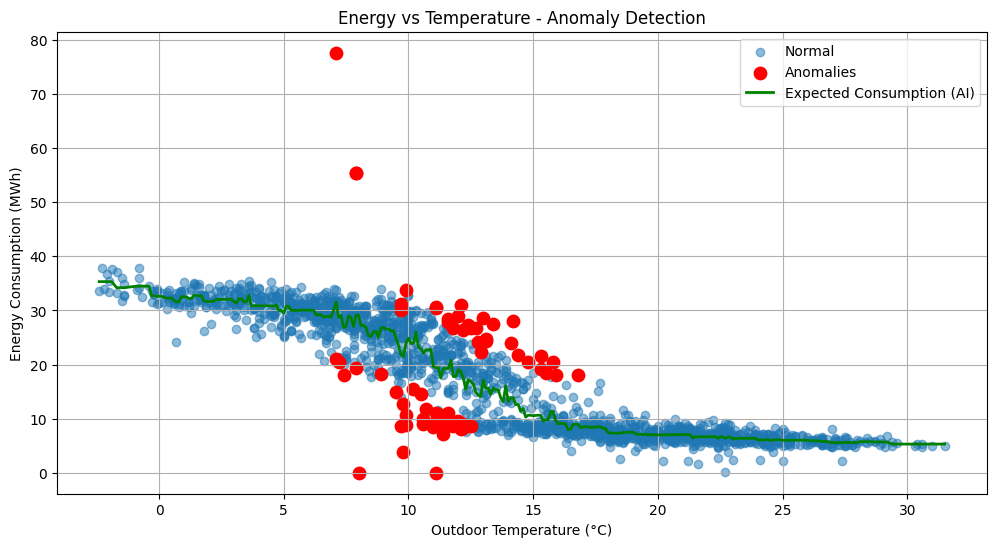

In [ ]:
# ============================================
# 1. UNIR ENERGÍA + TEMPERATURA --> Develop a model that learns normal operational patterns, average efficient energy behaviour, and the relationship between outdoor temperature and energy consumption.
# ============================================

model_data = pd.merge(
    daily,
    weather[["fecha", "temp_avg"]],
    on="fecha",
    how="inner"
)

# ============================================
# 2. FEATURES IA
# ============================================

X = model_data[["temp_avg"]]

y = model_data["total_energy"]

# ========================================================
# 3. ENTRENAR XGBOOST con histórico de datos
# ========================================================

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4
)

model.fit(X, y)

# ====================================================================================================================
# 4. CONSUMO ESPERADO (el patrón promedio aprendido por IA con el histórico de datos de los años anteriores)
# ====================================================================================================================

model_data["expected_energy"] = model.predict(X)

# ============================================
# 5. ERROR (ANOMALÍA)
# ============================================

model_data["error"] = abs(
    model_data["total_energy"] -
    model_data["expected_energy"]
)

# ============================================
# 6. DEFINIR ANOMALÍAS
# ============================================

threshold = model_data["error"].mean() + (
    2 * model_data["error"].std()
)

anomalies = model_data[
    model_data["error"] > threshold
]

# ============================================
# 7. SCATTER PLOT
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# puntos normales
plt.scatter(
    model_data["temp_avg"],
    model_data["total_energy"],
    alpha=0.5,
    label="Normal"
)

# anomalías
plt.scatter(
    anomalies["temp_avg"],
    anomalies["total_energy"],
    color="red",
    s=80,
    label="Anomalies"
)

# línea IA
sorted_data = model_data.sort_values("temp_avg")

plt.plot(
    sorted_data["temp_avg"],
    sorted_data["expected_energy"],
    color="green",
    linewidth=2,
    label="Expected Consumption (AI)"
)

plt.xlabel("Outdoor Temperature (°C)")
plt.ylabel("Energy Consumption (MWh)")

plt.title("Energy vs Temperature - Anomaly Detection")

plt.legend()
plt.grid(True)

plt.show()


# ============================================
# Blue points represent all days from the historical dataset.
# The green line shows the expected global energy consumption behaviour learned by the AI model.
# Red points indicate anomalous historical days with abnormal energy consumption patterns.
# ============================================



¿Fecha inicio? (YYYY-MM-DD): 2022-01-01
¿Fecha fin? (YYYY-MM-DD): 2022-12-31


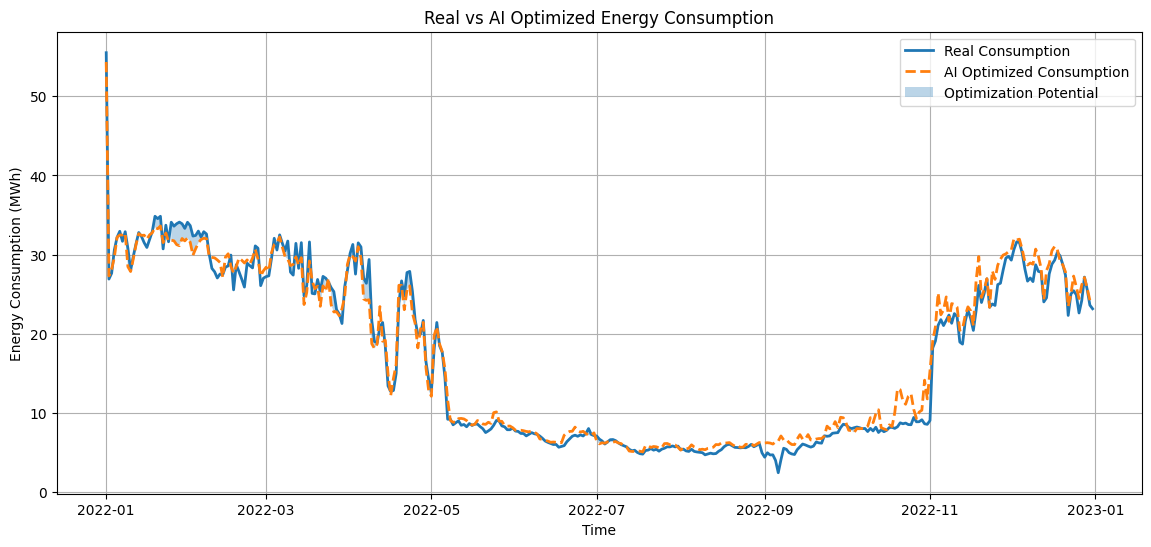


========== ENERGY SAVINGS ==========
Potential Energy Savings: 108.13 MWh
Potential Saving Percentage: 1.72%


In [ ]:
# ============================================
# REAL vs AI OPTIMIZED ENERGY CONSUMPTION
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# ============================================
# 1. CREAR VARIABLES TEMPORALES
# ============================================

model_data["month"] = model_data["fecha"].dt.month
model_data["day_of_year"] = model_data["fecha"].dt.dayofyear
model_data["day_of_week"] = model_data["fecha"].dt.dayofweek

# ============================================
# 2. FEATURES IA
# ============================================

X = model_data[
    [
        "temp_avg",
        "month",
        "day_of_year",
        "day_of_week"
    ]
]

y = model_data["total_energy"]

# ============================================
# 3. ENTRENAR MODELO XGBOOST
# ============================================

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

model.fit(X, y)

# ============================================
# 4. GENERAR CONSUMO OPTIMIZADO
# ============================================

model_data["optimized_energy"] = model.predict(X)

# ============================================
# 5. PEDIR RANGO DE FECHAS
# ============================================

start_date = input("¿Fecha inicio? (YYYY-MM-DD): ")
end_date = input("¿Fecha fin? (YYYY-MM-DD): ")

start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)

# ============================================
# 6. FILTRAR RANGO
# ============================================

range_data = model_data[
    (model_data["fecha"] >= start_date) &
    (model_data["fecha"] <= end_date)
].copy()

# ============================================
# 7. GRÁFICA REAL vs OPTIMIZED
# ============================================

plt.figure(figsize=(14,6))

# CONSUMO REAL
plt.plot(
    range_data["fecha"],
    range_data["total_energy"],
    linewidth=2,
    label="Real Consumption"
)

# CONSUMO OPTIMIZADO IA
plt.plot(
    range_data["fecha"],
    range_data["optimized_energy"],
    linestyle="--",
    linewidth=2,
    label="AI Optimized Consumption"
)

# ============================================
# 8. ÁREA DE POTENCIAL AHORRO
# ============================================

plt.fill_between(
    range_data["fecha"],
    range_data["total_energy"],
    range_data["optimized_energy"],
    where=(
        range_data["total_energy"] >
        range_data["optimized_energy"]
    ),
    alpha=0.3,
    label="Optimization Potential"
)

# ============================================
# 9. FORMATO
# ============================================

plt.title("Real vs AI Optimized Energy Consumption")

plt.xlabel("Time")
plt.ylabel("Energy Consumption (MWh)")

plt.legend()
plt.grid(True)

plt.show()


# ====================================================================================================================
# 10. CALCULAR POTENCIAL AHORRO --> Estimates the potential energy savings based on the AI-optimized time series.
# ====================================================================================================================

range_data["saving_potential"] = (
    range_data["total_energy"] -
    range_data["optimized_energy"]
)

# solo positivos
range_data["saving_potential"] = (
    range_data["saving_potential"]
    .clip(lower=0)
)

# ============================================
# 11. RESULTADOS
# ============================================

total_savings = range_data["saving_potential"].sum()

real_total = range_data["total_energy"].sum()

saving_percent = (
    total_savings / real_total
) * 100

# ============================================
# 12. MOSTRAR RESULTADOS
# ============================================

print("\n========== ENERGY SAVINGS ==========")

print(f"Potential Energy Savings: {total_savings:.2f} MWh")

print(f"Potential Saving Percentage: {saving_percent:.2f}%")



Would you like me to estimate the future energy consumption optimization and the potential energy savings? (Yes/No): yes
Which year would you like to forecast? (Example: 2026): 2026

Generating optimization forecast for 2026...

========== FUTURE ENERGY OPTIMIZATION ==========
Estimated Future Energy Savings: 975.14 MWh
Estimated Saving Percentage: 13.04%


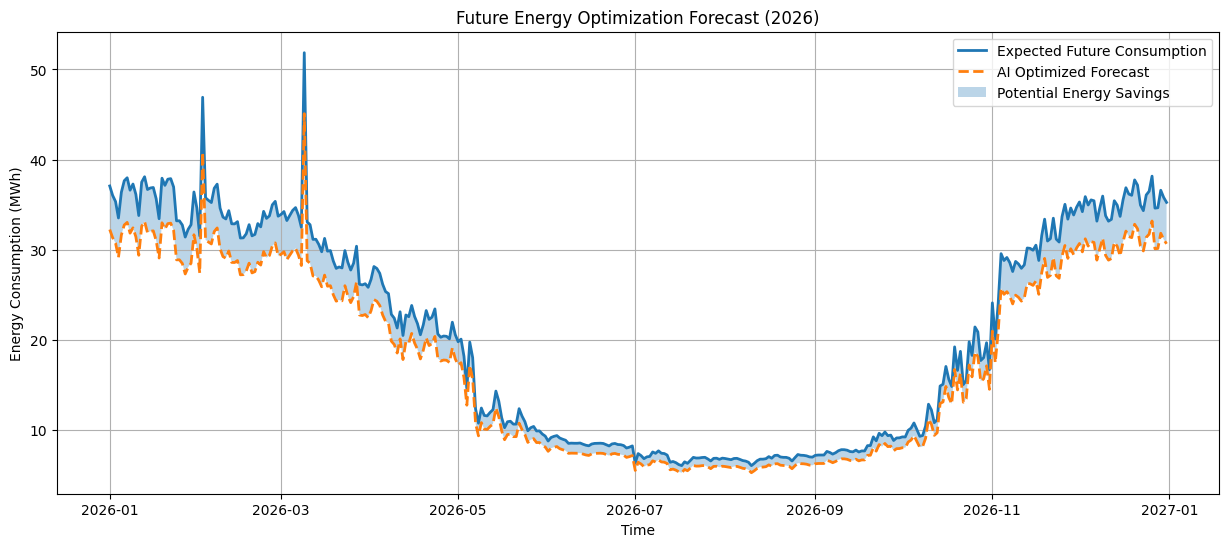


The estimated economic saving would be = 87762.57 € per year
The estimated CO2 emissions saving would be = 195.03 tCO2 per year
The estimated economic saving per dwelling would be = 58.51 € per year
The estimated energy saving per dwelling would be = 650.09 kWh per year


In [ ]:
# =====================================================
# FUTURE ENERGY OPTIMIZATION FORECAST
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# =====================================================
# 1. USER QUESTION
# =====================================================

answer = input(
    "Would you like me to estimate the future energy consumption optimization and the potential energy savings? (Yes/No): "
)

# =====================================================
# 2. CONTINUE ONLY IF YES
# =====================================================

if answer.lower() == "yes":

    # =====================================================
    # 3. ASK FORECAST YEAR
    # =====================================================

    selected_year = input(
        "Which year would you like to forecast? (Example: 2026): "
    )

    selected_year = int(selected_year)

    print(f"\nGenerating optimization forecast for {selected_year}...")

    # =====================================================
    # 4. PREPARE HISTORICAL DATA
    # =====================================================

    model_data["month"] = model_data["fecha"].dt.month

    model_data["day_of_year"] = (
        model_data["fecha"].dt.dayofyear
    )

    model_data["day_of_week"] = (
        model_data["fecha"].dt.dayofweek
    )

    # =====================================================
    # 5. TRAIN AI MODEL
    # =====================================================

    X_train = model_data[
        [
            "temp_avg",
            "month",
            "day_of_year",
            "day_of_week"
        ]
    ]

    y_train = model_data["total_energy"]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5
    )

    model.fit(X_train, y_train)

    # =====================================================
    # 6. CREATE FUTURE DATES
    # =====================================================

    future_dates = pd.date_range(
        start=f"{selected_year}-01-01",
        end=f"{selected_year}-12-31",
        freq="D"
    )

    future_forecast = pd.DataFrame({
        "fecha": future_dates
    })

    # =====================================================
    # 7. GENERATE FUTURE TEMPERATURES
    # =====================================================

    # baseline climático histórico

    temp_baseline = weather.groupby(
        ["month", "day"]
    )["temp_avg"].mean().reset_index()

    # añadir mes y día
    future_forecast["month"] = (
        future_forecast["fecha"].dt.month
    )

    future_forecast["day"] = (
        future_forecast["fecha"].dt.day
    )

    # merge temperatura esperada
    future_forecast = pd.merge(
        future_forecast,
        temp_baseline,
        on=["month", "day"],
        how="left"
    )

    # =====================================================
    # 8. FUTURE FEATURES
    # =====================================================

    future_forecast["day_of_year"] = (
        future_forecast["fecha"].dt.dayofyear
    )

    future_forecast["day_of_week"] = (
        future_forecast["fecha"].dt.dayofweek
    )

    # =====================================================
    # 9. AI OPTIMIZED FORECAST
    # Generated by the AI using: historical energy data, historical weather data,learned operational patterns, estimated future outdoor temperature conditions.
    # =====================================================

    future_forecast["optimized_future_energy"] = model.predict(

        future_forecast[
            [
                "temp_avg",
                "month",
                "day_of_year",
                "day_of_week"
            ]
        ]
    )

    # =====================================================
    # 10. SIMULATED REAL FUTURE CONSUMPTION
    # =====================================================

    future_forecast["expected_real_energy"] = (

        future_forecast["optimized_future_energy"] * 1.15
    )

    # =====================================================
    # 11. FUTURE SAVINGS
    # =====================================================

    future_forecast["future_savings"] = (

        future_forecast["expected_real_energy"] -

        future_forecast["optimized_future_energy"]
    )


    # =====================================================
    # 12. RESULTS
    # =====================================================

    total_future_savings = (
        future_forecast["future_savings"].sum()
    )

    savings_percent = (
        future_forecast["future_savings"].sum() /

        future_forecast["expected_real_energy"].sum()
    ) * 100

    print("\n========== FUTURE ENERGY OPTIMIZATION ==========")

    print(
        f"Estimated Future Energy Savings: "
        f"{total_future_savings:.2f} MWh"
    )

    print(
        f"Estimated Saving Percentage: "
        f"{savings_percent:.2f}%"
    )


    # =====================================================
    # 13. GRAPH
    # Blue → Expected future energy consumption under current operating conditions
    # Orange → AI-optimized energy consumption forecast
    # Shaded blue area → Potential energy savings
    # =====================================================

    plt.figure(figsize=(15,6))

    # expected future real consumption
    plt.plot(
        future_forecast["fecha"],
        future_forecast["expected_real_energy"],
        linewidth=2,
        label="Expected Future Consumption"
    )

    # AI optimized forecast
    plt.plot(
        future_forecast["fecha"],
        future_forecast["optimized_future_energy"],
        linestyle="--",
        linewidth=2,
        label="AI Optimized Forecast"
    )

    # savings area
    plt.fill_between(
        future_forecast["fecha"],
        future_forecast["expected_real_energy"],
        future_forecast["optimized_future_energy"],
        alpha=0.3,
        label="Potential Energy Savings"
    )

    plt.title(
        f"Future Energy Optimization Forecast ({selected_year})"
    )

    plt.xlabel("Time")
    plt.ylabel("Energy Consumption (MWh)")

    plt.legend()
    plt.grid(True)

    plt.show()

# =====================================================
# 14. IF NO
# =====================================================

else:

    print("Process cancelled.")


# ============================================
# ECONOMIC & CO2 SAVINGS
# ============================================

energy_price = 90   # €/MWh
co2_factor = 0.2    # tCO2/MWh

# total dwellings
total_dwellings = 1500

# ============================================
# GLOBAL SAVINGS
# ============================================

economic_savings = (
    total_future_savings * energy_price
)

co2_savings = (
    total_future_savings * co2_factor
)

# ============================================
# SAVINGS PER DWELLING
# ============================================

saving_per_dwelling = (
    economic_savings / total_dwellings
)

energy_saving_per_dwelling = (
    (total_future_savings * 1000) / total_dwellings
)

# ============================================
# SHOW RESULTS
# ============================================

print(
    f"\nThe estimated economic saving would be = "
    f"{economic_savings:.2f} € per year"
)

print(
    f"The estimated CO2 emissions saving would be = "
    f"{co2_savings:.2f} tCO2 per year"
)

print(
    f"The estimated economic saving per dwelling would be = "
    f"{saving_per_dwelling:.2f} € per year"
)

print(
    f"The estimated energy saving per dwelling would be = "
    f"{energy_saving_per_dwelling:.2f} kWh per year"
)

Would you like to generate the future energy optimization forecast using XGBoost and LSTM? (Yes/No): yes
Which year would you like to forecast? (Example: 2027): 2026

Generating AI optimization forecast for 2026...

=========== XGBOOST RESULTS ===========
Estimated Energy Saving = 975.14 MWh/year
Estimated Economic Saving = 87762.57 €/year
Estimated CO2 Saving = 195.03 tCO2/year
Estimated Saving per Dwelling = 58.51 €/year

=========== LSTM RESULTS ===========
Estimated Energy Saving = 1045.16 MWh/year
Estimated Economic Saving = 94064.34 €/year
Estimated CO2 Saving = 209.03 tCO2/year
Estimated Saving per Dwelling = 62.71 €/year


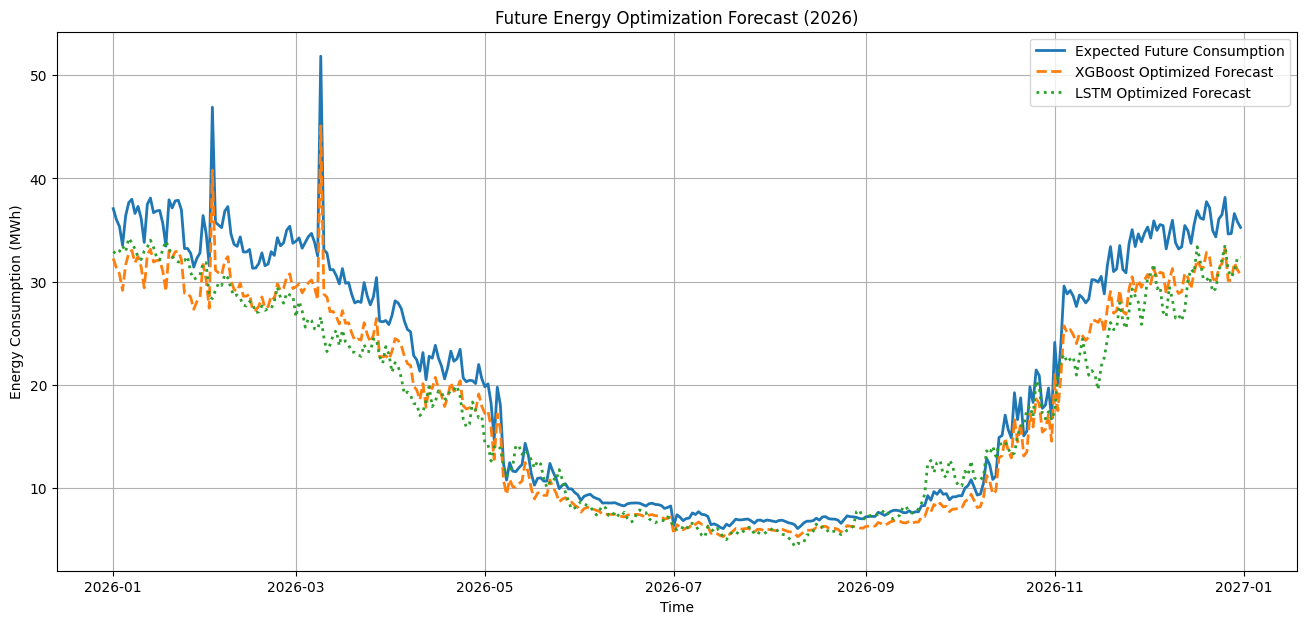

In [51]:
# =====================================================
# FUTURE ENERGY OPTIMIZATION
# COMPARISON: XGBOOST vs LSTM
# =====================================================

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# =====================================================
# USER INPUT
# =====================================================

answer = input(
    "Would you like to generate the future energy optimization forecast using XGBoost and LSTM? (Yes/No): "
)

if answer.lower() == "yes":

    # =====================================================
    # FORECAST YEAR
    # =====================================================

    selected_year = input(
        "Which year would you like to forecast? (Example: 2027): "
    )

    selected_year = int(selected_year)

    print(f"\nGenerating AI optimization forecast for {selected_year}...")

    # =====================================================
    # PREPARE HISTORICAL DATA
    # =====================================================

    model_data["month"] = model_data["fecha"].dt.month

    model_data["day_of_year"] = (
        model_data["fecha"].dt.dayofyear
    )

    model_data["day_of_week"] = (
        model_data["fecha"].dt.dayofweek
    )

    # =====================================================
    # FEATURES
    # =====================================================

    X = model_data[
        [
            "temp_avg",
            "month",
            "day_of_year",
            "day_of_week"
        ]
    ]

    y = model_data["total_energy"]

    # =====================================================
    # XGBOOST MODEL
    # =====================================================

    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5
    )

    xgb_model.fit(X, y)

    # =====================================================
    # FUTURE DATES
    # =====================================================

    future_dates = pd.date_range(
        start=f"{selected_year}-01-01",
        end=f"{selected_year}-12-31",
        freq="D"
    )

    future_forecast = pd.DataFrame({
        "fecha": future_dates
    })

    # =====================================================
    # TEMPERATURE BASELINE
    # =====================================================

    temp_baseline = weather.groupby(
        ["month", "day"]
    )["temp_avg"].mean().reset_index()

    future_forecast["month"] = (
        future_forecast["fecha"].dt.month
    ).copy()

    future_forecast["day"] = (
        future_forecast["fecha"].dt.day
    ).copy()

    future_forecast = pd.merge(
        future_forecast,
        temp_baseline,
        on=["month", "day"],
        how="left"
    ).copy()

    future_forecast["day_of_year"] = (
        future_forecast["fecha"].dt.dayofyear
    ).copy()

    future_forecast["day_of_week"] = (
        future_forecast["fecha"].dt.dayofweek
    ).copy()

    # =====================================================
    # XGBOOST FORECAST
    # =====================================================

    future_forecast["xgb_optimized_energy"] = (

        xgb_model.predict(

            future_forecast[
                [
                    "temp_avg",
                    "month",
                    "day_of_year",
                    "day_of_week"
                ]
            ]
        )
    )

    # =====================================================
    # LSTM MODEL
    # =====================================================

    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_x.fit_transform(X)
    y_scaled = scaler_y.fit_transform(
        y.values.reshape(-1,1)
    )

    # reshape for LSTM
    X_lstm = X_scaled.reshape(
        X_scaled.shape[0],
        1,
        X_scaled.shape[1]
    )

    # =====================================================
    # BUILD LSTM
    # =====================================================

    lstm_model = Sequential()

    lstm_model.add(
        LSTM(
            50,
            activation='relu',
            input_shape=(1, X_scaled.shape[1])
        )
    )

    lstm_model.add(Dense(1))

    lstm_model.compile(
        optimizer='adam',
        loss='mse'
    )

    # =====================================================
    # TRAIN LSTM
    # =====================================================

    lstm_model.fit(
        X_lstm,
        y_scaled,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    # =====================================================
    # FUTURE DATA FOR LSTM
    # =====================================================

    future_X = future_forecast[
        [
            "temp_avg",
            "month",
            "day_of_year",
            "day_of_week"
        ]
    ]

    future_X_scaled = scaler_x.transform(future_X)

    future_X_lstm = future_X_scaled.reshape(
        future_X_scaled.shape[0],
        1,
        future_X_scaled.shape[1]
    )

    # =====================================================
    # LSTM FORECAST
    # =====================================================

    lstm_pred_scaled = lstm_model.predict(
        future_X_lstm,
        verbose=0
    )

    lstm_pred = scaler_y.inverse_transform(
        lstm_pred_scaled
    )

    future_forecast["lstm_optimized_energy"] = (
        lstm_pred.flatten()
    )

    # =====================================================
    # SIMULATED FUTURE REAL CONSUMPTION
    # =====================================================

    future_forecast["expected_real_energy"] = (
        future_forecast["xgb_optimized_energy"] * 1.15
    )

    # =====================================================
    # ENERGY SAVINGS
    # =====================================================

    future_forecast["xgb_savings"] = (
        future_forecast["expected_real_energy"] -
        future_forecast["xgb_optimized_energy"]
    ).copy()

    future_forecast["lstm_savings"] = (
        future_forecast["expected_real_energy"] -
        future_forecast["lstm_optimized_energy"]
    ).copy()

    # =====================================================
    # TOTAL SAVINGS
    # =====================================================

    xgb_total_savings = (
        future_forecast["xgb_savings"].sum()
    )

    lstm_total_savings = (
        future_forecast["lstm_savings"].sum()
    )

    # =====================================================
    # ECONOMIC & CO2
    # =====================================================

    energy_price = 90
    co2_factor = 0.2
    total_dwellings = 1500

    # XGB
    xgb_cost_saving = (
        xgb_total_savings * energy_price
    )

    xgb_co2_saving = (
        xgb_total_savings * co2_factor
    )

    xgb_dwelling_saving = (
        xgb_cost_saving / total_dwellings
    )

    # LSTM
    lstm_cost_saving = (
        lstm_total_savings * energy_price
    )

    lstm_co2_saving = (
        lstm_total_savings * co2_factor
    )

    lstm_dwelling_saving = (
        lstm_cost_saving / total_dwellings
    )

    # =====================================================
    # RESULTS
    # =====================================================

    print("\n=========== XGBOOST RESULTS ===========")

    print(
        f"Estimated Energy Saving = "
        f"{xgb_total_savings:.2f} MWh/year"
    )

    print(
        f"Estimated Economic Saving = "
        f"{xgb_cost_saving:.2f} €/year"
    )

    print(
        f"Estimated CO2 Saving = "
        f"{xgb_co2_saving:.2f} tCO2/year"
    )

    print(
        f"Estimated Saving per Dwelling = "
        f"{xgb_dwelling_saving:.2f} €/year"
    )

    print("\n=========== LSTM RESULTS ===========")

    print(
        f"Estimated Energy Saving = "
        f"{lstm_total_savings:.2f} MWh/year"
    )

    print(
        f"Estimated Economic Saving = "
        f"{lstm_cost_saving:.2f} €/year"
    )

    print(
        f"Estimated CO2 Saving = "
        f"{lstm_co2_saving:.2f} tCO2/year"
    )

    print(
        f"Estimated Saving per Dwelling = "
        f"{lstm_dwelling_saving:.2f} €/year"
    )

    # =====================================================
    # GRAPH
    # =====================================================

    plt.figure(figsize=(16,7))

    # REAL
    plt.plot(
        future_forecast["fecha"],
        future_forecast["expected_real_energy"],
        linewidth=2,
        label="Expected Future Consumption"
    )

    # XGB
    plt.plot(
        future_forecast["fecha"],
        future_forecast["xgb_optimized_energy"],
        linestyle="--",
        linewidth=2,
        label="XGBoost Optimized Forecast"
    )

    # LSTM
    plt.plot(
        future_forecast["fecha"],
        future_forecast["lstm_optimized_energy"],
        linestyle=":",
        linewidth=2,
        label="LSTM Optimized Forecast"
    )

    plt.title(
        f"Future Energy Optimization Forecast ({selected_year})"
    )

    plt.xlabel("Time")
    plt.ylabel("Energy Consumption (MWh)")

    plt.legend()

    plt.grid(True)

    plt.show()

else:

    print("Process cancelled.")